# 第 8 章 策略監控、資產配置與自動下單

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/8-1_trading_portfolio.ipynb)

**對應影片**：第 8 章 單元 8-1【雲端自動化】Colab 加密貨幣策略監控系統、8-2 加密貨幣資產配置系統、8-3 資產配置系統 - 詳細解析、8-4 串接 Binance API 自動下單調整策略部位

**和影片的差異**

- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。價格、交易對資訊也一樣，所以監控與回測在 Colab 可以正常執行。
- **重要**：下單使用 `api.binance.com`，它會拒絕美國 IP（HTTP 451）。Colab 主機在美國，所以 Colab 上只能 dry run（計算訊號與訂單、不送出）。真正下單請在自己的電腦（台灣）執行，或部署到 asia-east1（台灣）的 Cloud Function（見 8-5）。
- API 金鑰不要寫在筆記本裡（分享或上傳 GitHub 就外洩了）。本機執行時用環境變數 `BINANCE_KEY`、`BINANCE_SECRET` 提供；沒有設定時自動 dry run。
- VETBTC 已於 2026 年 3 月下架，altcoin 策略改用 BNBBTC。
- `tp.status()` 會直接畫出每個策略的累積報酬並列出表格，下方的選單可以逐一檢視策略。

In [1]:
%pip install -q "finlab_crypto[trade]==0.3.0"

Note: you may need to restart the kernel to use updated packages.


# 定義策略

`TradingMethod`：一個策略 + 一組幣種 + 部位大小。

In [2]:
from finlab_crypto.indicators import trends
from finlab_crypto.online import TradingMethod, TradingPortfolio
from finlab_crypto.strategy import Strategy


@Strategy(name='sma', n1=20, n2=40)
def trend_strategy(ohlcv):
    fast = trends[trend_strategy.name](ohlcv.close, trend_strategy.n1)
    slow = trends[trend_strategy.name](ohlcv.close, trend_strategy.n2)

    entries = (fast > slow) & (fast.shift() < slow.shift())
    exits = (fast < slow) & (fast.shift() > slow.shift())

    figures = {
        'overlaps': {
            'trend1': fast,
            'trend2': slow,
        }
    }
    return entries, exits, figures


# altcoin 策略：每個幣種用 0.2 BTC 的部位
tm1 = TradingMethod(
    symbols=['XRPUSDT', 'ADAUSDT', 'LINKUSDT', 'ETHBTC', 'BNBBTC'],
    freq='4h',
    lookback=1500,  # 計算訊號用的 K 線數量
    strategy=trend_strategy,
    variables=dict(name='sma', n1=30, n2=130),
    filters={},
    weight_btc=0.2,
    name='altcoin-trend-sma',
)

# BTC 策略：1 BTC 的部位
tm2 = TradingMethod(
    symbols=['BTCUSDT'],
    freq='4h',
    lookback=1500,
    strategy=trend_strategy,
    variables=dict(name='hullma', n1=70, n2=108),
    filters={},
    weight_btc=1,
    name='btc-trend-hullma',
)

### 每個幣種用不同的部位

`weight_btc` 也可以給 dict，例如 ETH 用 0.5 BTC、其他 altcoin 用 0.2 BTC：

```python
weight_btc = {'ETHBTC': 0.5, 'default': 0.2}
```

也可以用 USDT 計價：`weight=500, weight_unit='USDT'`。

# 建立交易組合（TradingPortfolio）

**重要**：下單使用 `api.binance.com`，它會拒絕美國 IP（HTTP 451）。Colab 主機在美國，所以 Colab 上只能 dry run（計算訊號與訂單、不送出）。真正下單請在自己的電腦（台灣）執行，或部署到 asia-east1（台灣）的 Cloud Function（見 8-5）。

API 金鑰不要寫在筆記本裡（分享或上傳 GitHub 就外洩了）。本機執行時用環境變數 `BINANCE_KEY`、`BINANCE_SECRET` 提供；沒有設定時自動 dry run。

In [3]:
import os

BINANCE_KEY = os.environ.get('BINANCE_KEY')
BINANCE_SECRET = os.environ.get('BINANCE_SECRET')

tp = TradingPortfolio(BINANCE_KEY, BINANCE_SECRET)
tp.register(tm1)
tp.register(tm2)
tp.register_margin('USDT', 15000)  # 另外保留 15000 USDT 不參與策略
print('dry run（不會下單）' if tp.is_dry_run else '已連線幣安帳戶')

dry run（不會下單）


# 8-1 策略監控：回測所有策略

XRPUSDT 4h: 18382 candles (2018-05-04 ~ 2026-09-24 08:00 UTC)


ADAUSDT 4h: 18485 candles (2018-04-17 ~ 2026-09-24 08:00 UTC)


LINKUSDT 4h: 16844 candles (2019-01-16 ~ 2026-09-24 08:00 UTC)


ETHBTC 4h: 20140 candles (2017-07-14 ~ 2026-09-24 08:00 UTC)


BNBBTC 4h: 20140 candles (2017-07-14 ~ 2026-09-24 08:00 UTC)


BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


XRPBTC 4h: 19474 candles (2017-11-02 ~ 2026-09-24 08:00 UTC)


ADABTC 4h: 19304 candles (2017-11-30 ~ 2026-09-24 08:00 UTC)


LINKBTC 4h: 19683 candles (2017-09-28 ~ 2026-09-24 08:00 UTC)


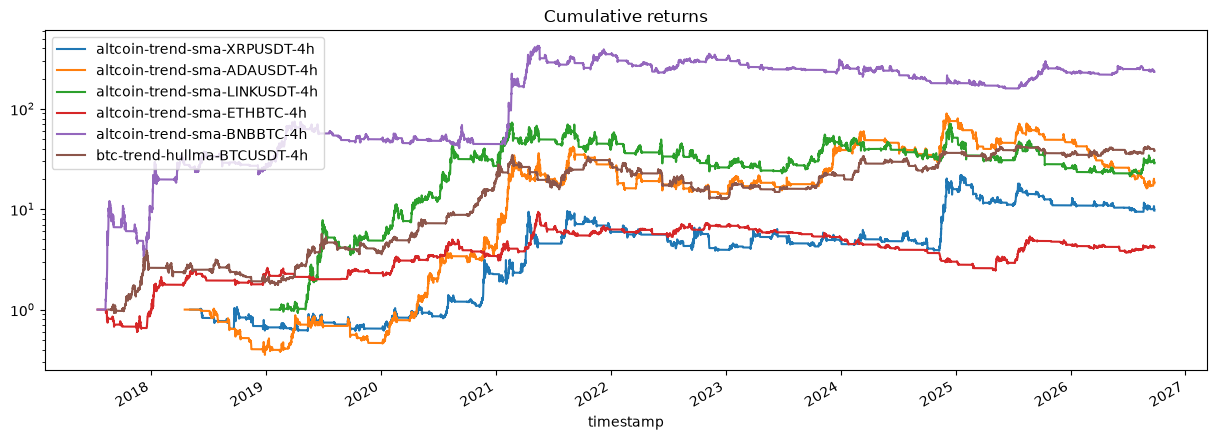

,name,symbol,freq,weight,signal
0,altcoin-trend-sma,XRPUSDT,4h,0.2,True
1,altcoin-trend-sma,ADAUSDT,4h,0.2,True
2,altcoin-trend-sma,LINKUSDT,4h,0.2,True
3,altcoin-trend-sma,ETHBTC,4h,0.2,True
4,altcoin-trend-sma,BNBBTC,4h,0.2,False
5,btc-trend-hullma,BTCUSDT,4h,1.0,True


In [4]:
import finlab_crypto

finlab_crypto.setup()
full_ohlcvs = tp.get_full_ohlcvs()
tp.status(full_ohlcvs)

## 整個帳戶的回測（以 USDT 計價）

ADAUSDT 4h: 18485 candles (2018-04-17 ~ 2026-09-24 08:00 UTC)


BNBUSDT 4h: 19451 candles (2017-11-06 ~ 2026-09-24 08:00 UTC)


BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


ETHUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


LINKUSDT 4h: 16844 candles (2019-01-16 ~ 2026-09-24 08:00 UTC)


XRPUSDT 4h: 18382 candles (2018-05-04 ~ 2026-09-24 08:00 UTC)


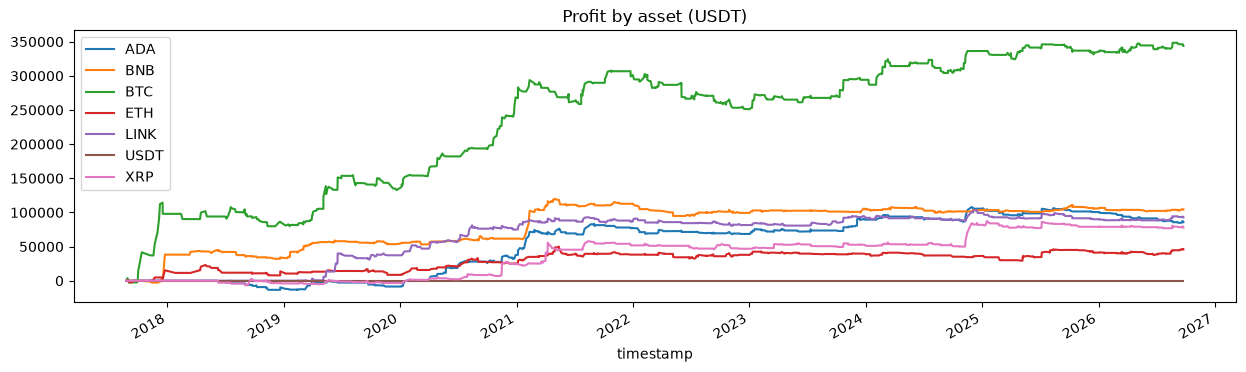

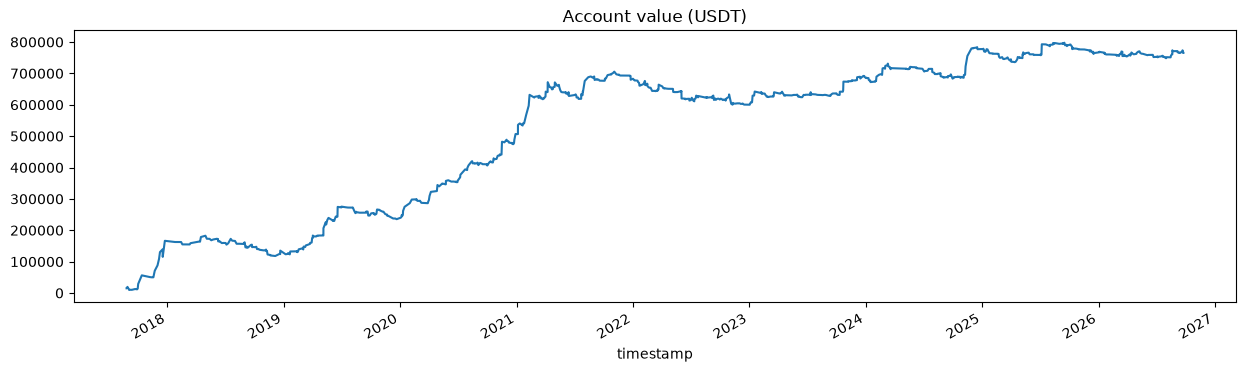

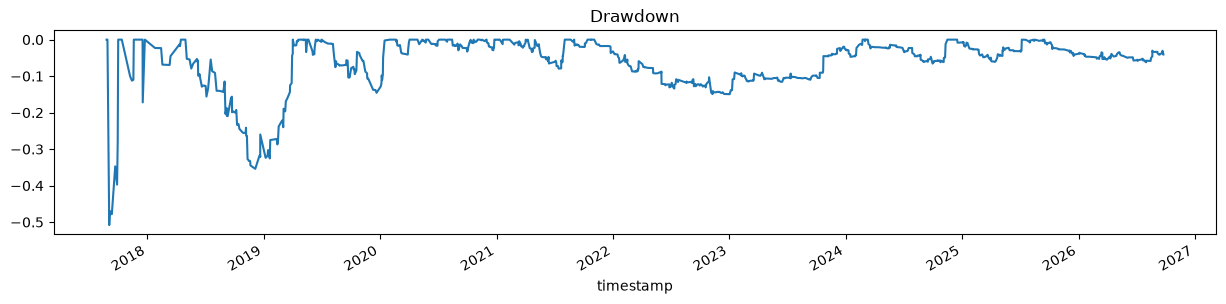

,name,symbol,freq,weight,portfolio,trading_method,signal
0,altcoin-trend-sma,XRPUSDT,4h,0.2,"Portfolio(**Config({\n ""wrapper"": ""<vectorb...",<finlab_crypto.online.TradingMethod object at ...,True
1,altcoin-trend-sma,ADAUSDT,4h,0.2,"Portfolio(**Config({\n ""wrapper"": ""<vectorb...",<finlab_crypto.online.TradingMethod object at ...,True
2,altcoin-trend-sma,LINKUSDT,4h,0.2,"Portfolio(**Config({\n ""wrapper"": ""<vectorb...",<finlab_crypto.online.TradingMethod object at ...,True
3,altcoin-trend-sma,ETHBTC,4h,0.2,"Portfolio(**Config({\n ""wrapper"": ""<vectorb...",<finlab_crypto.online.TradingMethod object at ...,True
4,altcoin-trend-sma,BNBBTC,4h,0.2,"Portfolio(**Config({\n ""wrapper"": ""<vectorb...",<finlab_crypto.online.TradingMethod object at ...,False
5,btc-trend-hullma,BTCUSDT,4h,1.0,"Portfolio(**Config({\n ""wrapper"": ""<vectorb...",<finlab_crypto.online.TradingMethod object at ...,True


In [5]:
asset_returns = tp.portfolio_backtest(full_ohlcvs, '4h')
asset_returns

# 最新訊號

`get_ohlcvs()` 只抓每個策略需要的最近 `lookback` 根 K 線，比較快。

In [6]:
ohlcvs = tp.get_ohlcvs()
signals = tp.get_latest_signals(ohlcvs)
signals

,symbol,method name,latest_signal,weight_btc,freq,return,amount,value_in_btc,latest_price,entry_price,entry_time,html
0,XRPUSDT,altcoin-trend-sma,True,0.2,4h,-0.000597,11481.056257,0.201378,1.506500,1.50740,2026-09-21 16:00:00+00:00,None
1,ADAUSDT,altcoin-trend-sma,True,0.2,4h,0.093948,72727.272727,0.205091,0.242200,0.22140,2026-09-20 08:00:00+00:00,None
2,LINKUSDT,altcoin-trend-sma,True,0.2,4h,-0.003115,1297.016861,0.190272,12.482000,12.52100,2026-09-20 20:00:00+00:00,None
3,ETHBTC,altcoin-trend-sma,True,0.2,4h,0.010787,6.345178,0.201586,0.031860,0.03152,2026-09-09 20:00:00+00:00,None
4,BNBBTC,altcoin-trend-sma,False,0.2,4h,0.000000,0.000000,0.000000,0.009178,0.00000,0,None
5,BTCUSDT,btc-trend-hullma,True,1.0,4h,-0.025146,1.000000,1.000000,84524.020000,86704.27000,2026-09-23 00:00:00+00:00,None


# 8-2、8-3 資產配置：計算目標部位與訂單

`calculate_position_size` 把所有策略的部位加總（以 BTC 計價），和帳戶目前的部位比較：

| 欄位 | 意義 |
|---|---|
| `algo_p` | 策略要的部位 |
| `margin_p` | `register_margin` 保留的部位 |
| `estimate_p` | 目標部位 = algo_p + margin_p |
| `present_p` | 帳戶目前的部位（dry run 時為 0） |
| `difference` | 需要調整的量 |

**範例**：tm1 有 5 個 xxxBTC 交易對，每個 0.01 BTC；tm2 只有 BTCUSDT，0.03 BTC。
若 tm1 有 4 個進場、tm2 也進場，BTC 的部位是 +0.03（買 BTC）− 0.04（用 BTC 買 altcoin）= −0.01。
部位不能是負的，所以 BTC 目標部位歸零 —— 大量買進 altcoin 時，tm2 的 BTC 部位不論進場與否都會是 0。

In [7]:
position, position_in_btc, new_orders = tp.calculate_position_size(signals)
position_in_btc

,algo_p,margin_p,estimate_p,present_p,difference,rebalance_threshold,rebalance,excluded
ADA,0.205091,0.000000,0.205091,0.0,0.205091,0.006153,True,False
BNB,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,False,False
BTC,0.800000,0.000000,0.800000,0.0,0.800000,0.024000,True,False
ETH,0.201586,0.000000,0.201586,0.0,0.201586,0.006048,True,False
LINK,0.190272,0.000000,0.190272,0.0,0.190272,0.005708,True,False
USDT,-1.600000,0.180252,-1.419748,0.0,0.000000,0.042592,False,True
XRP,0.201378,0.000000,0.201378,0.0,0.201378,0.006041,True,False


In [8]:
new_orders

,value_in_btc,value,base_asset,quote_asset,price,final_value,final_value_in_btc
ADAUSDT,0.205091,72727.272727,ADA,USDT,0.2345,72727.2000,0.205091
BTCUSDT,0.800000,0.800000,BTC,USDT,83216.7400,0.8000,0.800000
ETHUSDT,0.201586,6.347176,ETH,USDT,2643.4100,6.3471,0.201584
LINKUSDT,0.190272,1297.016861,LINK,USDT,12.1700,1297.0100,0.190271
XRPUSDT,0.201378,11481.056257,XRP,USDT,1.4597,11481.0000,0.201377


# 8-4 下單

`mode`：

- `'TEST'`：送到幣安驗證但不成交（dry run 時只列出訂單）
- `'LIMIT'`：以最新價格掛限價單
- `'MARKET'`：市價單


### 下單前請注意

- 在幣安建立 API 金鑰時，只勾選「現貨交易」，**不要**開啟提現權限，並設定 IP 白名單。
- 交易的幣種很多時請用 `LIMIT` 單：曾有人在 MAX 交易所用市價單賣出 83 枚 BTC，成交價從 15000 被砸到 6000。
- 課程程式碼是公開的，每次下單前後都請人工確認部位與訂單；程式難免有 bug，造成的損失我們無法負責。
- 部署到雲端時請固定 `finlab_crypto` 的版本（例如 `==0.3.0`），避免套件更新改變行為。

In [9]:
order_results = tp.execute_orders(new_orders, mode='TEST')
order_results

|---------EXECUTION LOG----------|
| time: 2026-09-24 11:39:54 (dry run, nothing sent)
| TEST ADAUSDT BUY 72727.2 dry run
| TEST BTCUSDT BUY 0.8 dry run
| TEST ETHUSDT BUY 6.3471 dry run
| TEST LINKUSDT BUY 1297.01 dry run
| TEST XRPUSDT BUY 11481.0 dry run


,side,type,symbol,quantity,result
ADAUSDT,BUY,MARKET,ADAUSDT,72727.2,dry run
BTCUSDT,BUY,MARKET,BTCUSDT,0.8,dry run
ETHUSDT,BUY,MARKET,ETHUSDT,6.3471,dry run
LINKUSDT,BUY,MARKET,LINKUSDT,1297.01,dry run
XRPUSDT,BUY,MARKET,XRPUSDT,11481.0,dry run
